In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
import plotnine as p9
import liana as li
import muon as mu
import anndata as ad
import matplotlib.pyplot as plt
import squidpy as sq
from liana.method._pipe_utils._common import _get_props
from liana.method.sp._utils import _add_complexes_to_var
from liana._logging import _logg
from liana.method._pipe_utils import prep_check_adata, assert_covered
from scipy.sparse import csr_matrix

/g/stegle/aalsayah/Miniforge3/envs/liana_env/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
/g/stegle/aalsayah/Miniforge3/envs/liana_env/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
/g/stegle/aalsayah/Miniforge3/envs/liana_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.


## Load unprocessed adata

In [2]:
adata = sc.read("/g/stegle/aalsayah/repos/data/crc_wt_cosmx/crc_120.h5ad")

In [4]:
adata.obs["typ"].value_counts()

typ
120_CRC2    317011
120_CRC1    247891
120_TVA     117602
120_REF      25804
Name: count, dtype: int64

In [ ]:
adata_242 = sc.read("/g/stegle/aalsayah/repos/data/crc_wt_cosmx/crc_242.h5ad")

In [6]:
adata_242.obs["typ"].value_counts()

typ
242_TVA    287351
242_CRC     90167
242_REF     44315
Name: count, dtype: int64

In [ ]:
adata_210 = sc.read("/g/stegle/aalsayah/repos/data/crc_wt_cosmx/crc_210.h5ad")

In [ ]:
adata_242.obs["typ"].value_counts()

## Basic QC


In [9]:
# filter cells and genes
sc.pp.filter_cells(adata, min_genes=10)
sc.pp.filter_genes(adata, min_cells=3)

In [6]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [7]:
# Convert mm to um using global coordinates
adata.obs['CenterX_um'] = adata.obs['CenterX_global_mm'] * 1000
adata.obs['CenterY_um'] = adata.obs['CenterY_global_mm'] * 1000

In [8]:
#Extract coords and save them in obsm["spatial"], li.ut.spatial_neighbors() and squidpy functions like sq.gr.spatial_autocorr() look for spatial coordinates in adata.obsm["spatial"] by default.
coords = adata.obs[['CenterX_um', 'CenterY_um']].to_numpy()
adata.obsm["spatial"] = coords

In [11]:
adata.shape

(129915, 18935)

## Calculate spatial connectivity matrix Wij

In [12]:
li.ut.spatial_neighbors(adata=adata, bandwidth=50)

In [13]:
sq.gr.spatial_autocorr(adata, mode='moran', use_raw=False)

## Load processed adata

In [14]:
adata.write_h5ad("/g/stegle/aalsayah/repos/data/crc_wt_cosmx/232_processed_moran.h5ad")

In [2]:
adata = sc.read("/g/stegle/aalsayah/repos/data/crc_wt_cosmx/232_processed_moran.h5ad")

In [3]:
## Check how many spatially variable genes (SVGs)
svgs = adata.uns['moranI'].index[(adata.uns['moranI']['pval_norm_fdr_bh'] < 0.05) & (adata.uns['moranI']['I'] > 0.01)]
len(svgs)

1707

## Visualize proximity

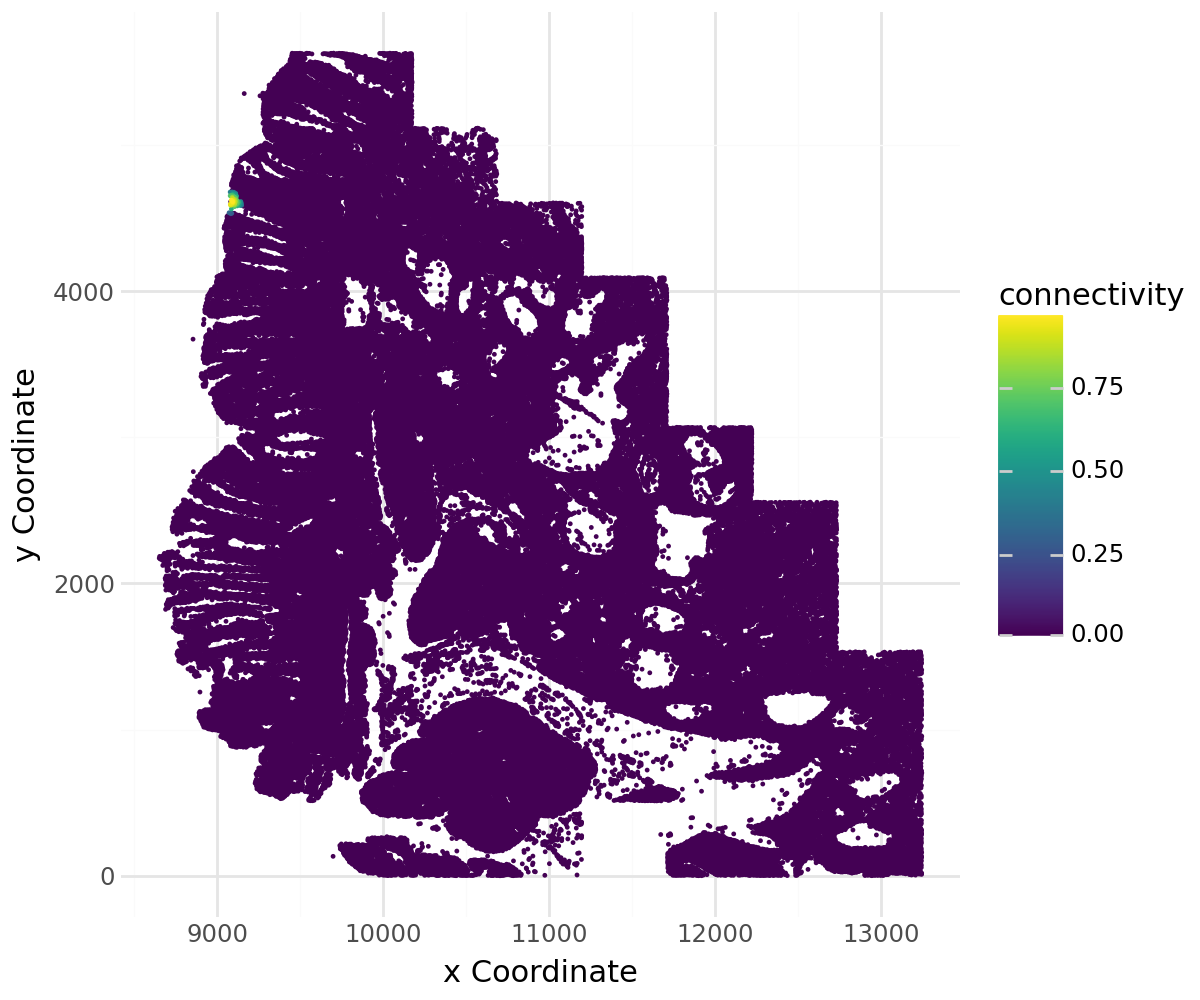

In [22]:
li.pl.connectivity(adata, idx=0, size=0.001, figure_size=(6, 5))

## inflow score

In [6]:
adata = adata[:, svgs]

In [7]:
adata

View of AnnData object with n_obs × n_vars = 129915 × 1707
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash', 'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name', 'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_

In [8]:
lrdata = li.mt.inflow(adata,  
                                  groupby='ist', # cell type columns
                                  resource_name='cellchatdb',
                                  use_raw=False)
lrdata.shape                             

/g/stegle/aalsayah/Miniforge3/envs/liana_env/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.


(129915, 784)

## Method 2 (original)

In [11]:
from docs.source.notebooks.original_inflow import SpatialInflow
inflow_ori = SpatialInflow()

In [12]:
res_ori, lrdata2 = inflow_ori(subset_adata,  
                                  groupby='ist', # cell type columns
                                  resource_name='cellchatdb',
                                  use_raw=False)
                                  
lrdata2.shape

/g/stegle/aalsayah/Miniforge3/envs/liana_env/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/g/stegle/aalsayah/repos/liana-py/docs/source/notebooks/original_inflow.py:184: RuntimeWarning: invalid value encountered in divide


(1000, 69)

In [13]:
res_ori.sort_values('value').tail()

,name,value
144,epi1^CEACAM1^CEACAM5^epi1,0.264252
288,epi2^APP^CD74^epi3,0.268911
821,mye2^LAMB1^CD44^PC_IgG,0.314004
820,mye2^FN1^CD44^PC_IgG,0.314004
592,epi4^APP^CD74^mye1,0.353342


## Compare two methods

In [50]:
# Convert sparse matrix to dense array
dense1 = lrdata1.X.toarray()

# Convert ArrayView to NumPy array if needed
dense2 = np.array(lrdata2.X)

# Check if they are exactly the same
are_equal = np.array_equal(dense1, dense2)

print("Are the matrices exactly the same?", are_equal)

Are the matrices exactly the same? False


In [51]:
# Convert sparse matrix to dense
dense_array = lrdata1.X.toarray()
# Create DataFrame
df = pd.DataFrame(dense_array, index=lrdata1.obs_names, columns=lrdata1.var_names)
df2 = pd.DataFrame(lrdata2.X, index=lrdata2.obs_names, columns=lrdata2.var_names)


In [52]:
import random

In [53]:
for _ in range(5):  # Run 5 random checks
    random_col = random.choice(df.columns)
    sum_df1 = df[random_col].sum()
    sum_df2 = df2[random_col].sum()
    
    print(f"\nRandomly selected column: {random_col}")
    print(f"Sum in df: {sum_df1}")
    print(f"Sum in df2: {sum_df2}")
    
    if sum_df1 == sum_df2:
        print("✅ The column sums are equal.")
    else:
        print("❌ The column sums are different.")



Randomly selected column: mye1^COL6A1^SDC1
Sum in df: 8.256488993569588
Sum in df2: 8.256488605717664
❌ The column sums are different.

Randomly selected column: epi4^MDK^NCL
Sum in df: 23.337965576861592
Sum in df2: 23.337965478418045
❌ The column sums are different.

Randomly selected column: epi2^COL9A2^SDC1
Sum in df: 4.8607958816061085
Sum in df2: 4.860795651803869
❌ The column sums are different.

Randomly selected column: epi2^LAMA3^CD44
Sum in df: 5.086199486709338
Sum in df2: 5.086199616425716
❌ The column sums are different.

Randomly selected column: epi4^MDK^SDC1
Sum in df: 2.229277950715357
Sum in df2: 2.2292780076141554
❌ The column sums are different.


## Create global score function

In [9]:
li.mt.compute_global_score(lrdata, groupby='ist')

/g/stegle/aalsayah/repos/liana-py/liana/method/sc/_compute_global_score.py:89: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.


In [10]:
lrdata.uns["global_score"].sort_values('lr_mean').tail()

,ligand,ligand_complex,receptor,receptor_complex,source,target,lr_mean
3380,MDK,MDK,NCL,NCL,epi4,epi4,0.219324
5075,COL1A1,COL1A1,SDC1,SDC1,fib2,fib2,0.229924
1700,MDK,MDK,NCL,NCL,epi2,epi2,0.236179
5044,COL1A1,COL1A1,CD44,CD44,fib2,fib2,0.255594
3517,COL1A1,COL1A1,SDC4,SDC4,fib2,epi4,0.287243


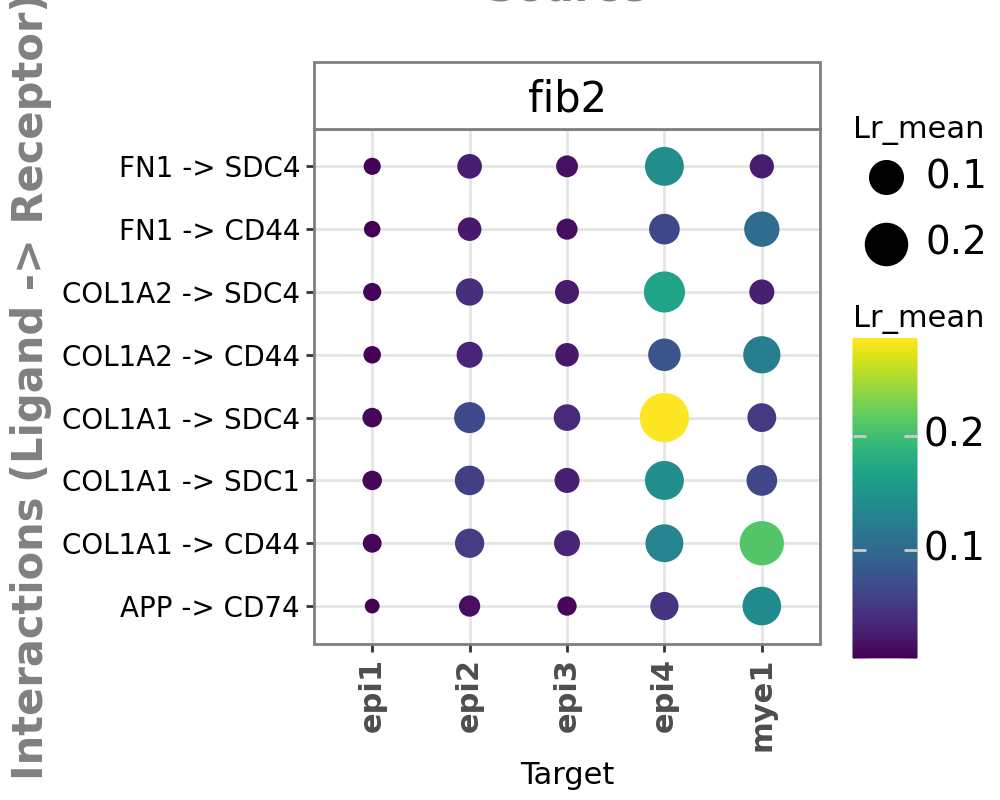

In [10]:
li.pl.dotplot(adata = lrdata, 
              colour='lr_mean',
              size = "lr_mean",
              source_labels=['fib2'],
              target_labels=['epi1', "epi4", "epi3", "epi2", "mye1"],
              filter_fun=lambda x: x['lr_mean'] > 0.1,
              figure_size=(5, 4),
              uns_key='global_score' 
             )

## Optional: filter data to keep only spatially variable LR interaction

In [11]:
sq.gr.spatial_autocorr(lrdata, mode='moran', use_raw=False)

In [12]:
svis = lrdata.uns['moranI'].index[(lrdata.uns['moranI']['pval_norm_fdr_bh'] <= 0.05) & (lrdata.uns['moranI']['I'] > 0.01)]

In [13]:
len(svis)

690

In [14]:
lrdata = lrdata[:,svis]
lrdata.uns['moranI'].sort_values("I").tail(10)

,I,pval_norm,var_norm,pval_norm_fdr_bh
fib2^CEACAM1^CEACAM5,0.217356,0.0,1.608876e-07,0.0
mye2^CEACAM1^CEACAM5,0.226716,0.0,1.608876e-07,0.0
mye1^CEACAM1^CEACAM5,0.241905,0.0,1.608876e-07,0.0
epi3^MDK^NCL,0.261539,0.0,1.608876e-07,0.0
epi4^MDK^NCL,0.326481,0.0,1.608876e-07,0.0
epi2^MDK^NCL,0.340160,0.0,1.608876e-07,0.0
epi3^CEACAM1^CEACAM5,0.376875,0.0,1.608876e-07,0.0
epi1^CEACAM1^CEACAM5,0.382330,0.0,1.608876e-07,0.0
epi2^CEACAM1^CEACAM5,0.392461,0.0,1.608876e-07,0.0
epi4^CEACAM1^CEACAM5,0.464224,0.0,1.608876e-07,0.0


In [39]:
adata.layers['transformed'] = li.utils.zi_minmax(adata.X, cutoff=0.01)

/tmp/ipykernel_2743269/3987365680.py:1: ImplicitModificationWarning: Setting element `.layers['transformed']` of view, initializing view as actual.


/tmp/ipykernel_2743269/2946928213.py:19: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
/tmp/ipykernel_2743269/2946928213.py:21: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
/tmp/ipykernel_2743269/2946928213.py:23: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
/tmp/ipykernel_2743269/2946928213.py:25: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
/tmp/ipykernel_2743269/2946928213.py:27: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
/tmp/ipykernel_2743269/2946928213.py:29: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


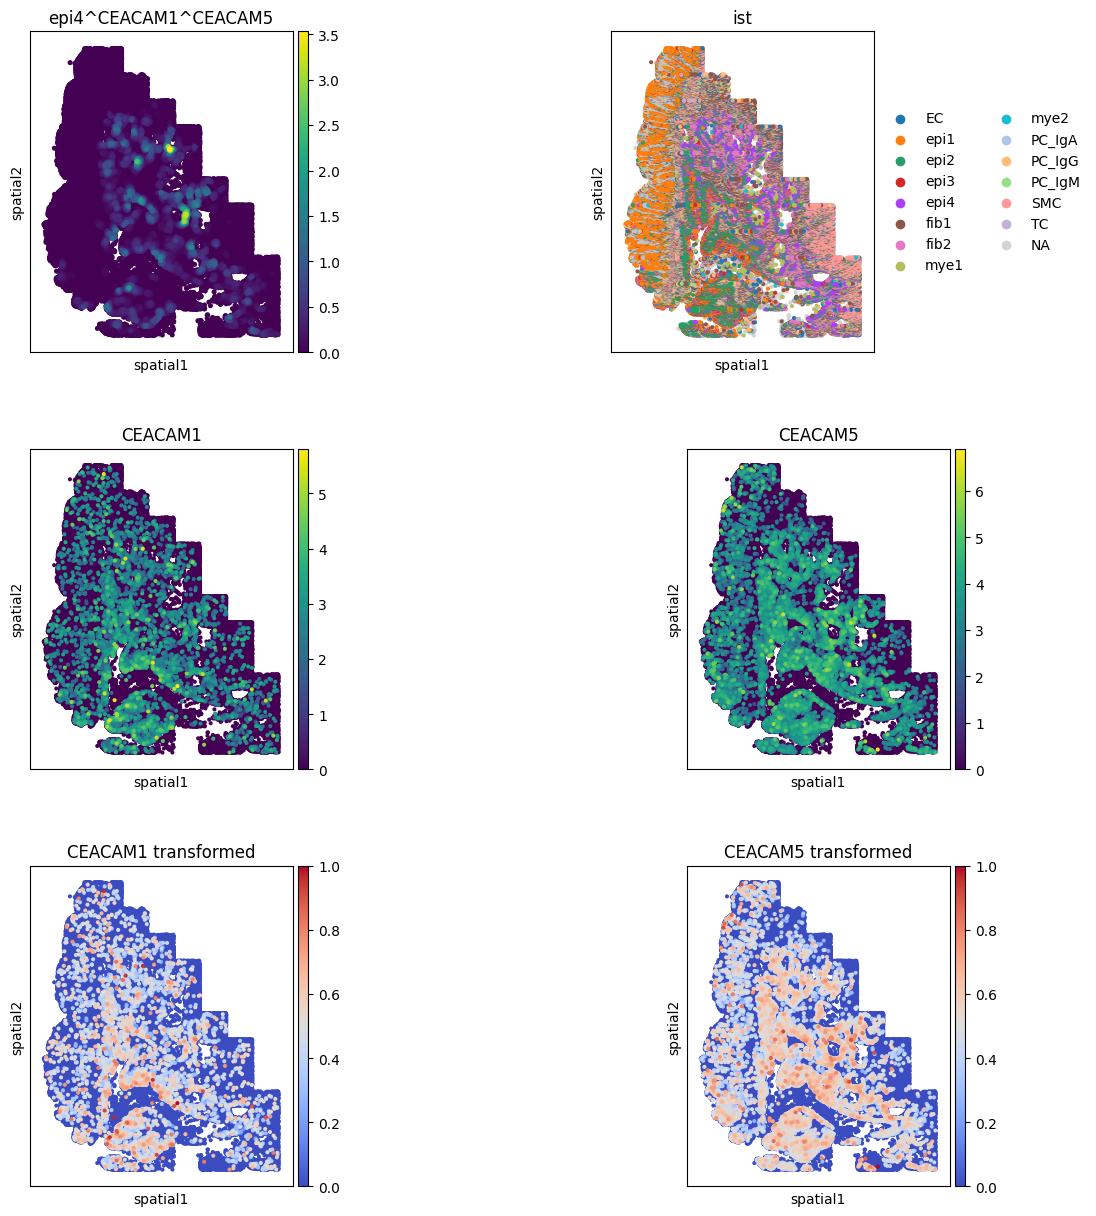

In [40]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
plt.subplots_adjust(hspace=0.3, wspace=0.3)
axes = axes.flatten()

# Define your keys
key = 'epi4^CEACAM1^CEACAM5' #NOTE @Moeed, sanity check interaction for Macrophage infiltration
xy_sep = '^'
groupby = 'ist'
keys = key.split(xy_sep)

if len(keys) < 2:
    raise ValueError("The 'key' variable should contain at least two elements separated by '&'.")

ligand = keys[1]
receptor = keys[2]

adata.obs['receptor'] = (adata[:, receptor].X > 0).toarray().flatten()

sc.pl.spatial(lrdata, color=[key], spot_size=100, ax=axes[0],show=False)
axes[0].set_title(f"{key}")
sc.pl.spatial(adata, color=[groupby], spot_size=80, ax=axes[1],show=False)
axes[1].set_title(f"{groupby}")
sc.pl.spatial(adata, color=[ligand], spot_size=80, ax=axes[2], show=False)
axes[2].set_title(f"{ligand}")
sc.pl.spatial(adata, color=[receptor], spot_size=80, ax=axes[3], show=False)
axes[3].set_title(f"{receptor}")
sc.pl.spatial(adata, color=[ligand], spot_size=80, ax=axes[4], show=False, layer='transformed', cmap='coolwarm')
axes[4].set_title(f"{ligand} transformed")
sc.pl.spatial(adata, color=[receptor], spot_size=80, ax=axes[5], show=False, layer='transformed', cmap='coolwarm')
axes[5].set_title(f"{receptor} transformed")
plt.show()

# MOFA-Flex

## Create a Multi-View Structure

In [ ]:
#lrdata.write_h5ad("/g/stegle/aalsayah/repos/data/lrdata/lrdata_232.h5ad")

In [ ]:
from pathlib import Path
data_path = Path("/g/stegle/aalsayah/repos/liana-py/inflow_score_different_annotation")

In [36]:
lrdata = sc.read_h5ad(data_path/  "inflow_score_jst.h5ad")

In [37]:
var_names = lrdata.var_names
prefixes = var_names.str.extract(r"^(.*?)\^")[0].unique()
prefixes

array(['epi.stress', 'epi_MSLN', 'epi.2', 'epi.3', 'epi.4',
       'epi_KLK10/CLDN2', 'epi_MUC5AC', 'epi_LGR5', 'epi.goblet', 'Bm',
       'macro1', 'epi.entero', 'CAF_CTHRC1', 'CAF_F3', 'cDC1', 'LEC',
       'CAF_NOTCH3', 'Th', 'Tc', 'fib.TLS', 'epi.EE', 'BEC', 'IAF_MMP',
       'PC_IgM', 'fib', 'fib_PI16', 'PC_IgG', 'nphil', 'PC_IgA2',
       'fib_NR4A1', 'fib_ADAM', 'PC_IgA1', 'fib_PDGFRA', 'SMC'],
      dtype=object)

In [38]:
# Replace ., -, / with _
lrdata.var_names = lrdata.var_names.str.replace(r"[.\-/]", "_", regex=True)

In [39]:
var_names = lrdata.var_names
prefixes = var_names.str.extract(r"^(.*?)\^")[0].unique()
prefixes

array(['epi_stress', 'epi_MSLN', 'epi_2', 'epi_3', 'epi_4',
       'epi_KLK10_CLDN2', 'epi_MUC5AC', 'epi_LGR5', 'epi_goblet', 'Bm',
       'macro1', 'epi_entero', 'CAF_CTHRC1', 'CAF_F3', 'cDC1', 'LEC',
       'CAF_NOTCH3', 'Th', 'Tc', 'fib_TLS', 'epi_EE', 'BEC', 'IAF_MMP',
       'PC_IgM', 'fib', 'fib_PI16', 'PC_IgG', 'nphil', 'PC_IgA2',
       'fib_NR4A1', 'fib_ADAM', 'PC_IgA1', 'fib_PDGFRA', 'SMC'],
      dtype=object)

In [40]:
views = {}

# Loop over each prefix and extract the corresponding view
for prefix in prefixes:
    # Filter variables that match this prefix
    matching_vars = var_names[var_names.str.startswith(f"{prefix}^")]
    
    # Subset the data for this view (only these variables)
    view_data = lrdata[:, matching_vars].copy()
    
    # Optionally remove prefix from var names for cleaner view
    #view_data.var.index = view_data.var.index.str.replace(f"{prefix}\^", "", regex=True)
    
    # Store the view
    views[prefix] = view_data

In [41]:
mdata = mu.MuData(views)

/g/stegle/aalsayah/Miniforge3/envs/liana_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/liana_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.


In [42]:
mdata.mod

MuData
├─ epi_stress AnnData (129915 x 51)
├─ epi_MSLN AnnData (129915 x 51)
├─ epi_2 AnnData (129915 x 53)
├─ epi_3 AnnData (129915 x 50)
├─ epi_4 AnnData (129915 x 51)
├─ epi_KLK10_CLDN2 AnnData (129915 x 56)
├─ epi_MUC5AC AnnData (129915 x 50)
├─ epi_LGR5 AnnData (129915 x 50)
├─ epi_goblet AnnData (129915 x 48)
├─ Bm AnnData (129915 x 34)
├─ macro1 AnnData (129915 x 50)
├─ epi_entero AnnData (129915 x 52)
├─ CAF_CTHRC1 AnnData (129915 x 53)
├─ CAF_F3 AnnData (129915 x 50)
├─ cDC1 AnnData (129915 x 49)
├─ LEC AnnData (129915 x 46)
├─ CAF_NOTCH3 AnnData (129915 x 49)
├─ Th AnnData (129915 x 48)
├─ Tc AnnData (129915 x 47)
├─ fib_TLS AnnData (129915 x 46)
├─ epi_EE AnnData (129915 x 48)
├─ BEC AnnData (129915 x 48)
├─ IAF_MMP AnnData (129915 x 50)
├─ PC_IgM AnnData (129915 x 47)
├─ fib AnnData (129915 x 49)
├─ fib_PI16 AnnData (129915 x 41)
├─ PC_IgG AnnData (129915 x 48)
├─ nphil AnnData (129915 x 44)
├─ PC_IgA2 AnnData (129915 x 49)
├─ fib_NR4A1 AnnData (129915 x 49)
├─ fib_ADAM Ann

In [43]:
# Loop through all modalities in mdata
for mod_name, adata in mdata.mod.items():
    print(f"Filtering {mod_name}...")
    sc.pp.filter_cells(adata, min_genes=5)
    sc.pp.filter_genes(adata, min_cells=3)

Filtering epi_stress...
Filtering epi_MSLN...
Filtering epi_2...
Filtering epi_3...
Filtering epi_4...
Filtering epi_KLK10_CLDN2...
Filtering epi_MUC5AC...
Filtering epi_LGR5...
Filtering epi_goblet...
Filtering Bm...
Filtering macro1...
Filtering epi_entero...
Filtering CAF_CTHRC1...
Filtering CAF_F3...
Filtering cDC1...
Filtering LEC...
Filtering CAF_NOTCH3...
Filtering Th...
Filtering Tc...
Filtering fib_TLS...
Filtering epi_EE...
Filtering BEC...
Filtering IAF_MMP...
Filtering PC_IgM...
Filtering fib...
Filtering fib_PI16...
Filtering PC_IgG...
Filtering nphil...
Filtering PC_IgA2...
Filtering fib_NR4A1...
Filtering fib_ADAM...
Filtering PC_IgA1...
Filtering fib_PDGFRA...
Filtering SMC...


In [44]:
mdata.mod

MuData
├─ epi_stress AnnData (5721 x 51)
├─ epi_MSLN AnnData (3267 x 51)
├─ epi_2 AnnData (6618 x 53)
├─ epi_3 AnnData (12582 x 50)
├─ epi_4 AnnData (3498 x 51)
├─ epi_KLK10_CLDN2 AnnData (5184 x 56)
├─ epi_MUC5AC AnnData (3661 x 50)
├─ epi_LGR5 AnnData (1282 x 50)
├─ epi_goblet AnnData (225 x 46)
├─ Bm AnnData (0 x 0)
├─ macro1 AnnData (6656 x 50)
├─ epi_entero AnnData (287 x 52)
├─ CAF_CTHRC1 AnnData (7528 x 53)
├─ CAF_F3 AnnData (9755 x 50)
├─ cDC1 AnnData (922 x 49)
├─ LEC AnnData (75 x 37)
├─ CAF_NOTCH3 AnnData (9203 x 49)
├─ Th AnnData (3592 x 48)
├─ Tc AnnData (82 x 36)
├─ fib_TLS AnnData (59 x 30)
├─ epi_EE AnnData (2550 x 48)
├─ BEC AnnData (1939 x 48)
├─ IAF_MMP AnnData (495 x 48)
├─ PC_IgM AnnData (190 x 41)
├─ fib AnnData (4532 x 49)
├─ fib_PI16 AnnData (92 x 29)
├─ PC_IgG AnnData (1898 x 48)
├─ nphil AnnData (19 x 19)
├─ PC_IgA2 AnnData (2976 x 49)
├─ fib_NR4A1 AnnData (836 x 46)
├─ fib_ADAM AnnData (1541 x 47)
├─ PC_IgA1 AnnData (1396 x 49)
├─ fib_PDGFRA AnnData (272 x 45

In [45]:
del mdata.mod['Bm']
from mudata import MuData
mdata_new = MuData({mod: ad for mod, ad in mdata.mod.items()})

/g/stegle/aalsayah/Miniforge3/envs/liana_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/liana_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.


In [46]:
mdata_new.write(data_path/  "mudata/232_mdata_jst.h5mu")

/g/stegle/aalsayah/Miniforge3/envs/liana_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/liana_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
